In [1]:
%matplotlib widget
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import jax
import jax.numpy as jnp
import pickle
from tqdm.auto import tqdm
from pathlib import Path
from copy import deepcopy

In [68]:
# run_dir = Path('/work/pi_kandread_umass_edu/tss-ml/runs/swot_q_lumped/base_config_20250512_133738')
run_dir = Path('/work/pi_kandread_umass_edu/tss-ml/runs/swot_q_lumped/no_swot_20250512_134851')

fig_dir = run_dir / "figures" / "attribution"
fig_dir.mkdir(exist_ok=True, parents=True)

In [69]:
df = pd.read_parquet(run_dir / 'figures' / 'attribution' / 'discharge_integrated_gradients.parquet')

In [29]:
features = ['ssrd_mean',  
'strd_mean',  
'ro_mean',    
'sro_mean',   
'e_mean',     
'tp_mean',    
'sp_mean',    
'd2m_mean',   
't2m_mean',   
'fal_mean',   
'd_wse',
'wse_u',
'wse_r_u',
'slope_u',
'slope_r_u',
'd_width',
'width_u',
'area_total',
'area_tot_u',
'area_detct',
'area_det_u',
'layovr_val',
'loc_offset',
'xtrk_dist',
'obs_frac_n',
'dark_frac']

bits = ['ice_clim_f_bit_0',
'xovr_cal_q_bit_0',
'reach_q_bit_0',
'reach_q_bit_1',
'reach_q_b_bit_0',
'reach_q_b_bit_1',
'reach_q_b_bit_2',
'reach_q_b_bit_3',
'reach_q_b_bit_4',
'reach_q_b_bit_5',
'reach_q_b_bit_6',
'reach_q_b_bit_7',
'reach_q_b_bit_8',
'reach_q_b_bit_9',
'reach_q_b_bit_10',
'reach_q_b_bit_11',
'reach_q_b_bit_12',
'reach_q_b_bit_13',
'reach_q_b_bit_14',
'reach_q_b_bit_15',
'reach_q_b_bit_16',
'reach_q_b_bit_17',
'reach_q_b_bit_18',
'reach_q_b_bit_19',
'reach_q_b_bit_20',
'reach_q_b_bit_21',
'reach_q_b_bit_22',
'reach_q_b_bit_23',
'reach_q_b_bit_24',
'reach_q_b_bit_25',
'reach_q_b_bit_26',
'reach_q_b_bit_27',
'reach_q_b_bit_28']

In [57]:
df

,,discharge,ssrd_mean,strd_mean,ro_mean,sro_mean,e_mean,tp_mean,sp_mean,d2m_mean,t2m_mean,...,reach_q_b_bit_19,reach_q_b_bit_20,reach_q_b_bit_21,reach_q_b_bit_22,reach_q_b_bit_23,reach_q_b_bit_24,reach_q_b_bit_25,reach_q_b_bit_26,reach_q_b_bit_27,reach_q_b_bit_28
basin,date,,,,,,,,,,,,,,,,,,,,,
7120452830,2023-10-29,70.813423,0.517801,-0.545455,-0.075534,-0.167389,-0.014009,-0.007200,0.791846,0.314772,-0.305637,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7121074480,2024-12-19,5.990215,0.524156,0.377614,-0.131564,-0.219051,-0.564577,-0.435337,0.367319,-0.474908,0.110681,...,-0.031604,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7120464020,2024-04-10,98.282936,0.219222,0.416877,0.023237,-0.121940,-0.246483,-0.174472,0.691902,-0.336717,0.545685,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7121018380,2024-09-11,135.380951,-0.306080,-0.496558,-0.086572,-0.019659,0.710754,0.030922,0.335505,0.419357,-0.453299,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7120502100,2024-10-13,2.094456,0.157312,-0.671178,-0.096552,-0.307784,0.280554,-0.271801,0.933877,0.400312,-0.484562,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7121092850,2024-05-10,1.254001,-0.375473,0.457245,-0.141109,-0.099885,-0.293732,-0.203196,-0.511837,-0.391742,0.096160,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7120467240,2023-06-26,56.509834,-0.555008,-0.223791,-0.071246,-0.113365,0.469955,0.024031,0.480278,0.280907,-0.191838,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7120510840,2023-12-28,93.834885,0.824360,0.158763,-0.142242,-0.169132,-0.623183,-0.016177,0.637575,-0.295950,0.203141,...,-0.241606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
importance = df.drop(columns=['discharge']).abs().replace(0,np.nan).mean()
importance.sort_values()
importance

ssrd_mean           0.389519
strd_mean           0.438393
ro_mean             0.104326
sro_mean            0.131914
e_mean              0.433888
                      ...   
reach_q_b_bit_24    0.140185
reach_q_b_bit_25    0.091700
reach_q_b_bit_26    0.147539
reach_q_b_bit_27    0.020702
reach_q_b_bit_28         NaN
Length: 69, dtype: float32

In [65]:
importance

area_tot_u          0.001240
area_det_u          0.001265
width_u             0.002233
reach_q_b_bit_4     0.013508
reach_q_b_bit_27    0.020702
                      ...   
reach_q_b_bit_16         NaN
reach_q_b_bit_20         NaN
reach_q_b_bit_21         NaN
reach_q_b_bit_22         NaN
reach_q_b_bit_28         NaN
Length: 69, dtype: float32

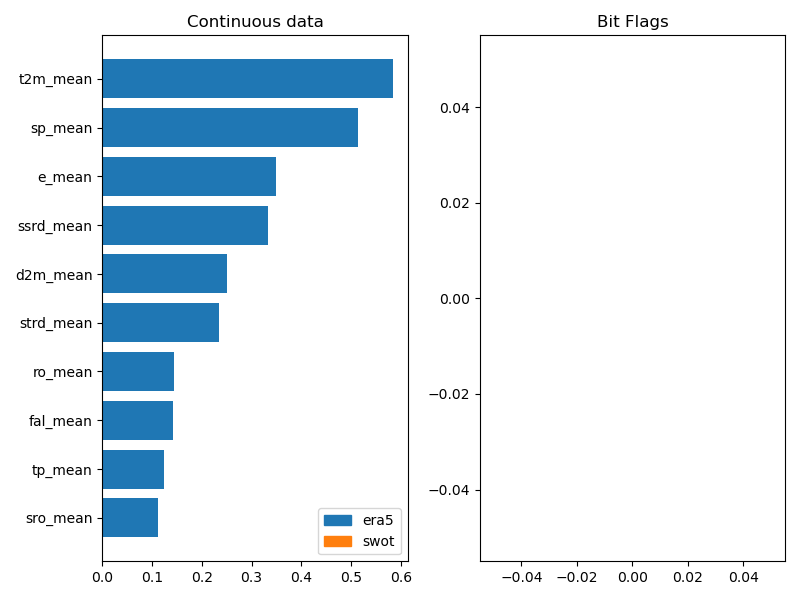

In [70]:
importance = df.drop(columns=['discharge']).abs().replace(0,np.nan).mean().dropna()
importance.sort_values(inplace=True)

is_feature = importance.index.isin(features)
feature_colors = ['tab:blue' if str(s).endswith('mean') else 'tab:orange' for s in importance.index[is_feature]]

is_bit = importance.index.isin(bits)
bit_colors = []

# Create legend patches
patches = [mpatches.Patch(color='tab:blue', label='era5'),
           mpatches.Patch(color='tab:orange', label='swot')]

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(8,6))

# ax.barh(labels, importance, color=colors)
axes[0].set_title('Continuous data')
axes[0].barh(importance.index[is_feature], importance.values[is_feature], color=feature_colors)
axes[0].legend(handles=patches, loc='lower right')

axes[1].set_title('Bit Flags')
axes[1].barh(importance.index[is_bit], importance.values[is_bit], color='tab:orange')

# Add the legend to the bottom right
# ax.legend(handles=patches, loc='lower right')


# ax.set_xlabel("Integrated Gradients")
# ax.set_xticks(tick)
# ax.ticklabel_format(style='sci', axis='x', useMathText=True, scilimits=(0,0))

plt.tight_layout()

fig.savefig(fig_dir / "feature_importance.png",  dpi=300)

In [45]:
feature_colors

['tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:orange',
 'tab:blue',
 'tab:orange',
 'tab:blue',
 'tab:blue',
 'tab:blue',
 'tab:blue',
 'tab:blue',
 'tab:blue',
 'tab:blue',
 'tab:blue',
 'tab:blue']

In [ ]:
np.linspace(0, 0.0004, 5)

In [ ]:
ax.set_xticks(np.linspace(0, 0.0004, 5))
fig.savefig(fig_dir / "q_feature_importance.png",  dpi=300)

In [ ]:
labels